# Úkol č. 1 - regrese

* Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML1/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html).
* Pokud odevzdáte úkol po prvním termínu, ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
* V rámci tohoto úkolu se musíte vypořádat s regresní úlohou, s příznaky různých typů a s chybějícími hodnotami.
* Před tím, než na nich postavíte predikční model, je třeba je nějakým způsobem převést do číselné reprezentace.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena.**
 
> **Minimalistické řešení nemůže získat plný počet bodů.**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budeme strhávat body.

## Zdroj dat

Budeme se zabývat predikcí ceny prodávaných automobilů.
K dispozici máte trénovací data v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:

* ID - identifikátor záznamu
* Make - výrobce vozidla
* Model - název modelu vozidla
* Price - prodejní cena; **cílová proměnná, kterou máte predikovat**
* Year - rok výroby
* Kilometer - počet najetých kilometrů
* Fuel Type - typ paliva
* Transmission - typ převodovky
* Location - město, kde k prodeji došlo
* Color - barva vozidla
* Owner - počet předchozích majitelů
* Seller Type - typ prodávajícího subjektu (osoba, firma)
* Engine - objem motoru v kubických centimetrech
* Max Power - maximální výkon motoru
* Max Torque - maximální kroutící moment motoru
* Drivetrain - typ poháněných náprav (FWD - pohon přední nápravy, RWD - pohon zadní nápravy, AWD - pohon všech náprav)
* Length - délka vozidla v mm
* Width - šířka vozidla v mm
* Height - výška vozidla v mm
* Seating Capacity - maximální počet míst k sezení
* Fuel Tank Capacity - kapacita nádrže v litrech


## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé a neminimalistické) vypracování získáte **25 bodů**: 
  * V notebooku načtěte data ze souboru `data.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování (trénovací), porovnávání modelů (validační) a následnou predikci výkonnosti finálního modelu (testovací).
    
  * Proveďte základní předzpracování dat:
    * Projděte si jednotlivé příznaky a transformujte je do vhodné podoby pro použití ve vybraném regresním modelu. Např. z příznaku `Engine` tedy vyextrahujte číselnou hodnotu.
    * Nějakým jednoduchým způsobem se vypořádejte s chybějícími hodnotami. (Např. nahrazujte vybranou konstantou. Doporučujeme nepoužívat žádnou sofistikovanou metodu!) _Pozor na metodické chyby!_
    * Můžete využívat i vizualizace. Vše stručně ale náležitě komentujte.
<br /><br />
  
  * Na připravená data postupně aplikujte alespoň 3 z regresních modelů, které jsme probírali: **rozhodovací strom**, **metoda nejbližších sousedů**, **lineární regrese**, **hřebenová regrese**. Pro každý z těchto modelů přiměřeně:
    * Okomentujte vhodnost daného modelu pro daný typ úlohy.
    * Experimentujte s normalizací (standardizace/min-max), pokud pro daný model očekáváte její příznivý vliv.
    * Vyberte si hlavní hyperparametry k ladění a najděte jejich nejlepší hodnoty (vzhledem k MSE).
    * Pro model s nejlepšími hodnotami hyperparametrů na validační množině určete jeho chybu pomocí MSE.
    * Získané výsledky vždy řádně okomentujte.
<br /><br />
  * Ze všech zkoušených možností v předchozím kroku vyberte finální model a správně odhadněte, jakou chybu měřenou pomocí RMSE (tj. odmocniny z MSE) můžete očekávat na nových datech, která jste doposud neměli k dispozici. _Pozor na metodické chyby!_
    
  * Nakonec načtěte vyhodnocovací data ze souboru `evaluation.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data. Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **Price** a jednotlivé body identifikujete pomocí sloupce **ID** (dodržte názvy sloupců!). Tento soubor též odevzdejte (uložte do repozitáře vedle notebooku).


      * Snažte se vše udělat tak, aby chyba odevzdaných predikcí na vyhodocovacím datasetu měřená pomocí RMSE byla menší než **765 000**. Pokud bude větší, přijdete o **3 body**.
      
      * Ukázka, jak by mělo vypadat prvních několik řádků souboru `results.csv` (obecně s jinými hodnotami Price):
  
```
ID,Price
548,450000
879,680000
...
```


## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html.

# Řešení
**Postup:**
* Import balíčků a načtení dat ✅
* Analýza dat ✅
* Rozdělení dat na trénovací, validační a testovací množiny ✅
* Zpracování dat ✅
* Učení jednotlivých modelů s různými parametry na trénovacích a validačních datech ✅
* Výběr nejlepšího modelu podle validačního RMSE ✅
* Realizace nejlepšího modelu ✅
* Odhad přesnosti na testovací množině ✅
* Skutečná predikce ✅

## Import balíčků a načtení dat:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import ParameterGrid

rd_seed = 42
data = pd.read_csv("data.csv")

## Analýza dat:

In [2]:
display(data.head())
data.info()

,ID,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,...,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,1036,BMW,X1 sDrive20d,3250000,2020,32005,Diesel,Automatic,Bangalore,Blue,...,Individual,1995 cc,184 bhp @ 4000 rpm,380 Nm @ 1750 rpm,RWD,4454.0,1798.0,1545.0,5.0,61.0
1,754,Land Rover,Evoque SE Dynamic,6500000,2021,12000,Diesel,Automatic,Hyderabad,White,...,Individual,1999 cc,177 bhp @ 4000 rpm,430 Nm @ 1750 rpm,AWD,4360.0,2120.0,1635.0,5.0,57.0
2,840,Maruti Suzuki,S-Cross Zeta 1.6,800000,2017,52836,Diesel,Manual,Ahmedabad,Blue,...,Individual,1598 cc,118 bhp @ 3750 rpm,320 Nm @ 1750 rpm,FWD,4300.0,1765.0,1590.0,5.0,48.0
3,1127,Land Rover,Evoque HSE,3800000,2017,50000,Diesel,Automatic,Mumbai,White,...,Individual,1999 cc,177 bhp @ 4000 rpm,430 Nm @ 1750 rpm,AWD,4360.0,2120.0,1635.0,5.0,57.0
4,271,BMW,3-Series 320d Luxury Line,2950000,2018,75000,Diesel,Automatic,Coimbatore,White,...,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,RWD,4633.0,1811.0,1429.0,5.0,57.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  1683 non-null   int64  
 1   Make                1683 non-null   object 
 2   Model               1683 non-null   object 
 3   Price               1683 non-null   int64  
 4   Year                1683 non-null   int64  
 5   Kilometer           1683 non-null   int64  
 6   Fuel Type           1683 non-null   object 
 7   Transmission        1683 non-null   object 
 8   Location            1683 non-null   object 
 9   Color               1683 non-null   object 
 10  Owner               1683 non-null   object 
 11  Seller Type         1683 non-null   object 
 12  Engine              1667 non-null   object 
 13  Max Power           1667 non-null   object 
 14  Max Torque          1667 non-null   object 
 15  Drivetrain          1618 non-null   object 
 16  Length

**1683 záznamů** - relativně málo.\
DataFrame obsahuje NaN hodnotu, které budeme muset nahradit.\
*Object* typy převedeme na *category* pokud je to vhodné, popřípadě *drop*.

## Rozdělení na trénovací, validační a testovací množiny:

In [3]:
# 60/20/20
Xtrain, Xrest, ytrain, yrest = train_test_split(
    data.drop(columns=['Price']), data['Price'], test_size=0.4, random_state=rd_seed
)

Xval, Xtest, yval, ytest = train_test_split(
    Xrest, yrest, test_size=0.5, random_state=rd_seed
)

## Zpracování dat:

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

def data_processing(data_set):
    """
    Function that takes general data_set and makes the simplest processing without any model requirements.
    """
    data_set_processed = data_set.copy() # Make a copy to not change the original

    # ID - drop ✅
    data_set_processed = data_set_processed.drop(columns=['ID'], errors='ignore')
    
    # Model, Location - drop ✅
    data_set_processed = data_set_processed.drop(columns=['Model', 'Location'], errors='ignore')
    
    # Engine ✅
    if not pd.api.types.is_float_dtype(data_set_processed['Engine']): # Avoids overwritting after multiple calls
        eng_mask = data_set_processed['Engine'].notna()
        data_set_processed.loc[eng_mask, 'Engine'] = \
            data_set_processed.loc[eng_mask, 'Engine'].str.split(r'[ @]').str[0].astype(float)
        data_set_processed['Engine'] = data_set_processed['Engine'].astype(float)

    # Max Power ✅
    if not pd.api.types.is_float_dtype(data_set_processed['Max Power']):
        pow_mask = data_set_processed['Max Power'].notna()
        data_set_processed.loc[pow_mask, 'Max Power'] = \
            data_set_processed.loc[pow_mask, 'Max Power'].str.split(r'[ @]').str[0].astype(float) # Skip rpms
        data_set_processed['Max Power'] = data_set_processed['Max Power'].astype(float)

    # Max Torque ✅
    if not pd.api.types.is_float_dtype(data_set_processed['Max Torque']):
        torq_mask = data_set_processed['Max Torque'].notna()
        data_set_processed.loc[torq_mask, 'Max Torque'] = \
            data_set_processed.loc[torq_mask, 'Max Torque'].str.split(r'[ @]').str[0].astype(float) # Skip rmps
        data_set_processed['Max Torque'] = data_set_processed['Max Torque'].astype(float)
    
    # Transmission ✅
    if 'Transmission' in data_set_processed.columns:
        data_set_processed['Automatic Transmission'] = \
            (data_set_processed['Transmission'] == 'Automatic') # Change to bool: Automatic: True, Manual: False
        data_set_processed.drop(columns=['Transmission'], inplace=True, errors='ignore') # Transmission -> Automatic Transmission
     
    # Owner - Ordinal Encoding ✅
    # We don't want 'UnRegistered Car's mess with order
    data_set_processed['Owner'] = data_set_processed['Owner'].replace('UnRegistered Car', np.nan)
    if not pd.api.types.is_integer_dtype(data_set_processed['Owner']): # Avoids overwritting
        owner_categories = pd.api.types.CategoricalDtype(
            categories=['First', 'Second', 'Third', 'Fourth', '4 or More'], ordered=True)

        data_set_processed['Owner'] = data_set_processed['Owner'].astype(owner_categories)
        data_set_processed['Owner'] = data_set_processed['Owner'].cat.codes
    
    return data_set_processed
# data_processing end


one_hot_cols = ['Make', 'Fuel Type', 'Color', 'Seller Type', 'Drivetrain']

ohe_drop = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

ohe_keep = OneHotEncoder(
    drop=None,
    handle_unknown='ignore',
    sparse_output=False
)

ohe_drop.fit(Xtrain[one_hot_cols])
ohe_keep.fit(Xtrain[one_hot_cols])

def data_one_hot(data_set, drop_first=False):
    """
    Encodes data_set using one-hot-encoding fitted on Xtrain
    """
    data_set_processed = data_set.copy()
    
    try:
        # Separate categorical and the rest
        other_cols = [c for c in data_set_processed.columns if c not in one_hot_cols]

        # Encode categorical
        if drop_first:
            ohe = ohe_drop
        else:
            ohe = ohe_keep

        cat_encoded = ohe.transform(data_set_processed[one_hot_cols])
        cat_encoded = pd.DataFrame(
            cat_encoded,
            columns=ohe.get_feature_names_out(one_hot_cols),
            index=data_set_processed.index
        )
        
        # Combine encoded with the rest
        data_set_processed_encoded = pd.concat([data_set_processed[other_cols], cat_encoded], axis=1)
    except ValueError:
        pass
    
    return data_set_processed_encoded

def drop_one_hot(data_set):
    """
    Drop columns that would be one-hot-encoded otherwise
    """
    data_set_processed = data_set.copy()

    # Drop the original categorical columns (if they still exist)
    data_set_processed = data_set_processed.drop(columns=one_hot_cols, errors='ignore')

    return data_set_processed


def impute_data(Xtr, data_set):
    """
    Imputes missing values either with median of Xtrain or with -1
    """
    data_set_processed = data_set.copy()
    
    numeric_cols = data_set_processed.select_dtypes(include=['int64', 'float64']).columns
    other_cols   = data_set_processed.columns.difference(numeric_cols)
    
    if len(numeric_cols) > 0:
        imputer_num   = SimpleImputer(strategy='median').fit(Xtr[numeric_cols])
        data_set_processed[numeric_cols] = imputer_num.transform(data_set_processed[numeric_cols])
    if len(other_cols)   > 0:
        imputer_other = SimpleImputer(strategy='constant', fill_value=-1).fit(Xtr[other_cols])
        data_set_processed[other_cols]   = imputer_other.transform(data_set_processed[other_cols])
    
    return data_set_processed

# To process manually:
'''
# Numeric Columns (int/float) --> scaling
numeric_cols = [
    'Year', 'Kilometer', 'Engine', 'Max Power', 'Max Torque',
    'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity'
]''';  

In [5]:
# Universal data processing no matter the model
Xtrain = data_processing(Xtrain)
Xval   = data_processing(Xval)
display(Xtrain)

,Make,Year,Kilometer,Fuel Type,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Automatic Transmission
756,Jeep,2017,57000,Diesel,White,0,Individual,1956.0,171.0,350.0,FWD,4395.0,1818.0,1640.0,5.0,60.0,False
458,Hyundai,2016,70500,Diesel,White,0,Individual,1396.0,89.0,220.0,FWD,3995.0,1760.0,1555.0,5.0,45.0,False
375,Mercedes-Benz,2018,24000,Diesel,Red,0,Individual,2143.0,134.0,300.0,FWD,4630.0,1777.0,1432.0,5.0,NaN,True
333,Toyota,2017,44000,Diesel,Black,1,Individual,2755.0,174.0,450.0,RWD,4795.0,1855.0,1835.0,7.0,80.0,True
1121,Maruti Suzuki,2011,42000,LPG,White,1,Individual,998.0,46.0,85.0,FWD,3595.0,1475.0,1700.0,5.0,28.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,Jeep,2022,2000,Petrol,Green,0,Individual,1368.0,161.0,250.0,FWD,4405.0,1818.0,1640.0,5.0,60.0,True
1294,Toyota,2017,49000,Diesel,White,1,Individual,2755.0,174.0,450.0,AWD,4795.0,1855.0,1835.0,7.0,80.0,True
860,Honda,2016,38000,Diesel,Brown,0,Individual,1498.0,99.0,200.0,FWD,4440.0,1695.0,1495.0,5.0,40.0,False
1459,BMW,2018,40937,Diesel,White,0,Individual,2993.0,258.0,560.0,RWD,4899.0,2094.0,1464.0,5.0,65.0,True


## Učení jednotlivých modelů :

Vytvoříme si placeholder pro nejlepší model.

In [6]:
MINIMAL_MSE_MODEL = {
    'model': None,
    'one-hot': None,
    'scaler': None,
    'params' : None,
    'mse': np.inf
}

MODELS = [] # All models

def min_mse(model, one_hot, scaler, params, new_mse):
    """
    Changes MINIMAL_MSE_MODEL if new_mse is smaller and adds the model to the list of **unique** models
    """
    global MINIMAL_MSE_MODEL
    
    # Create new model dict
    NEW_MODEL = {
        'model': model,
        'one-hot': one_hot,
        'scaler': scaler,
        'params': params,
        'mse': new_mse
    }

    # Add to list and sort by MSE
    if NEW_MODEL not in MODELS:
        MODELS.append(NEW_MODEL)
        MODELS.sort(key=lambda x: x['mse'])

    # Update minimal MSE model
    if new_mse < MINIMAL_MSE_MODEL['mse']:
        MINIMAL_MSE_MODEL = NEW_MODEL

def print_models(rmse=False):
    """
    Prints out models sorted by `mse` with individual attributes
    """
    if len(MODELS) == 0:
           print('No models yet')
    for model in MODELS:
        print(
            f"model: {model['model']}\t"
            f"one-hot: {model['one-hot']}\t"
            f"scaler: {model['scaler']},{'\t' if model['scaler'] is None else ''}\t"
            f"params: ...\t"
            f"{'mse' if not rmse else 'rmse'}: {model['mse'] if not rmse else np.sqrt(model['mse']):.3f}"
        )

Nejdříve zkusíme rozhodovací strom. U rozhodovacího stromu by neměla hrát roli normalizace/standardizace. Zkusíme dvě verze s one-hot-encodingem a bez.\
U rozhodovacího stromu očekávám docela dobré výsledky.\
Měl by být vhodný pro predikci ceny aut, protože umí přirozeně zachytit silně nelineární vztahy a interakce mezi vlastnostmi vozidel.

### Rozhodovací strom:

#### One-Hot-Encoding:

In [7]:
Xtrain_tree, ytrain_tree = Xtrain.copy(), ytrain.copy()
Xval_tree, yval_tree     = Xval.copy(), yval.copy()

# One-hot-encoding
Xtrain_tree = data_one_hot(Xtrain_tree)
Xval_tree   = data_one_hot(Xval_tree)

Data jsou zpracovaná, teď jdeme naučit a vybrat nejlepší strom.

In [8]:
from sklearn.tree import DecisionTreeRegressor

def train_tree(Xt, yt, Xv, yv):
    """
    Trains a regression tree on Xtrain, Xval sets with different parameters.
    """
    param_grid = {
        'max_depth': range(3, 21),
        'min_samples_leaf': range(2, 11, 2),
        'min_samples_split': range(2, 21, 2),
        'criterion': ['squared_error', 'friedman_mse'],
        'max_leaf_nodes': [None, 50, 100, 200]
    }
    param_comb = ParameterGrid(param_grid)

    train_tree_acc = []
    val_tree_acc = []

    for param in param_comb:
        reg = DecisionTreeRegressor(**param, random_state=rd_seed)
        reg.fit(Xt, yt)
        train_tree_acc.append(mean_squared_error(yt, reg.predict(Xt)))
        val_tree_acc.append(mean_squared_error(yv, reg.predict(Xv)))
    
    return param_comb[np.argmin(val_tree_acc)]

Teď jdeme skutečně vybrat nejlepší strom (a jeho parametry). Délku učení odhaduji z předešlých měření na 45s.

In [9]:
%%time

optimal_tree_params = train_tree(Xtrain_tree, ytrain_tree, Xval_tree, yval_tree)
#optimal_tree_params = {'min_samples_split': 14, 'min_samples_leaf': 6, 'max_leaf_nodes': None, 'max_depth': 7, 'criterion': 'squared_error'}
print(optimal_tree_params)

{'min_samples_split': 14, 'min_samples_leaf': 6, 'max_leaf_nodes': None, 'max_depth': 7, 'criterion': 'squared_error'}
CPU times: user 41.6 s, sys: 4.01 ms, total: 41.6 s
Wall time: 41.6 s


Teď, když máme optimální parametry, můžeme vytvořit optimální strom a vyzkoušet jeho validační chybu MSE.

In [10]:
reg = DecisionTreeRegressor(**optimal_tree_params, random_state=rd_seed)
reg.fit(Xtrain_tree, ytrain_tree)

train_mse_tree = mean_squared_error(ytrain_tree, reg.predict(Xtrain_tree))
valid_mse_tree = mean_squared_error(yval_tree, reg.predict(Xval_tree))

print(f"TREE MSE (train): \t{train_mse_tree:.0f}")
print(f"TREE MSE (valid): \t{valid_mse_tree:.0f}")

TREE MSE (train): 	328617418264
TREE MSE (valid): 	372772024433


Dostali jsme *nějaké* číslo, je nám zatím jedno, co znamená. Model přidáme do seznamu modelů a jdeme vyzkoušet ostatní modely a pak je porovnat.

In [11]:
min_mse(model='tree', one_hot=True, scaler=None, params=optimal_tree_params, new_mse=valid_mse_tree)

#### Bez one-hot-encodingu:

Zde bych očekával horší výsledek než u stromu s one-hot-encodingem, protože stromu zase tolik nevadí vysoka dimenzionalita, ale můžeme se takto zbavit důležitých příznaků.

In [12]:
Xtrain_tree, ytrain_tree = Xtrain.copy(), ytrain.copy()
Xval_tree, yval_tree     = Xval.copy(), yval.copy()

# Drop columns
Xtrain_tree = drop_one_hot(Xtrain_tree)
Xval_tree = drop_one_hot(Xval_tree)

Využijeme naší předešlou funkci a natrénujeme nový strom. Odhadovaná délka učení 40s.

In [13]:
%%time

optimal_tree_params = train_tree(Xtrain_tree, ytrain_tree, Xval_tree, yval_tree)
#optimal_tree_params = {'min_samples_split': 16, 'min_samples_leaf': 2, 'max_leaf_nodes': None, 'max_depth': 12, 'criterion': 'squared_error'}
print(optimal_tree_params)

{'min_samples_split': 16, 'min_samples_leaf': 2, 'max_leaf_nodes': None, 'max_depth': 12, 'criterion': 'squared_error'}
CPU times: user 33.8 s, sys: 5.98 ms, total: 33.8 s
Wall time: 33.8 s


Vytvoříme optimální strom a změříme jeho průměrnou kvadratickou chybu.

In [14]:
reg = DecisionTreeRegressor(**optimal_tree_params, random_state=rd_seed)
reg.fit(Xtrain_tree, ytrain_tree)

train_mse_tree = mean_squared_error(ytrain_tree, reg.predict(Xtrain_tree))
valid_mse_tree = mean_squared_error(yval_tree, reg.predict(Xval_tree))

print(f"TREE MSE (train): \t{train_mse_tree:.0f}")
print(f"TREE MSE (valid): \t{valid_mse_tree:.0f}")

TREE MSE (train): 	278198708352
TREE MSE (valid): 	455778498491


In [15]:
min_mse(model='tree', one_hot=False, scaler=None, params=optimal_tree_params, new_mse=valid_mse_tree)
print_models()

model: tree	one-hot: True	scaler: None,		params: ...	mse: 372772024432.953
model: tree	one-hot: False	scaler: None,		params: ...	mse: 455778498491.238


Skutečně vidíme, že pro strom bylo lepší použít one-hot-encoding. Teď se podíváme, jak na tom budou v porovnáním s ním ostatní modely.

### kNN:

U kNN je důležitá normalizace/standardizace dat kvůli různým jednotkám, které hrají roli v měření vzdálenosti. Zkusíme znovu použít one-hot-encoding, ale ten výrazně zvyšuje dimenzi, která je u kNN velkým nepřítelem, takže bych čekal, že model trénovaný na množinách s menším počtem příznaků dopadne lépe.

#### One-Hot-Encoding:

In [16]:
from sklearn.neighbors import KNeighborsRegressor

In [17]:
Xtrain_knn, ytrain_knn = Xtrain.copy(), ytrain.copy()
Xval_knn, yval_knn     = Xval.copy(), yval.copy()

# One-Hot-Encoding
Xtrain_knn = data_one_hot(Xtrain_knn)
Xval_knn   = data_one_hot(Xval_knn)

# Get rid off NaN values
Xtrain_knn = impute_data(Xtrain_knn, Xtrain_knn)
Xval_knn   = impute_data(Xtrain_knn, Xval_knn)

Znovu si vytvoříme pomocnou funkci.

In [18]:
def optimize_knn(Xt, yt, Xv, yv):
    """
    Trains knn model with various parameters on `standard`, `minmax` scalers and with `None`.
    """
    scalers = [None, "standard", "minmax"]

    best_overall = {
        "scaler": None,
        "params": None,
        "valid_mse": np.inf
    }

    for sc in scalers:
        Xtrain_knn_s = Xt.copy()
        Xval_knn_s = Xv.copy()
        if sc is not None:
            if sc == "standard":
                scaler = StandardScaler().fit(Xt)
            else:
                scaler = MinMaxScaler().fit(Xt)
            Xtrain_knn_s = scaler.transform(Xt)
            Xval_knn_s   = scaler.transform(Xv)


        param_grid = {
            'n_neighbors': range(3, 31),
            'weights': ['uniform', 'distance'],
            'metric': ['minkowski', 'manhattan', 'euclidean'],
        }
        param_comb = list(ParameterGrid(param_grid))

        for param in param_comb:
            reg = KNeighborsRegressor(**param)
            reg.fit(Xtrain_knn_s, yt)
            valid_mse = mean_squared_error(yv, reg.predict(Xval_knn_s))

            # Update best combination
            if valid_mse < best_overall["valid_mse"]:
                best_overall["valid_mse"] = valid_mse
                best_overall["params"] = param
                best_overall["scaler"] = sc
                
    return best_overall

In [19]:
# Get the optimal model
opt_knn = optimize_knn(Xtrain_knn, ytrain_knn, Xval_knn, yval_knn)

print(f"Best scaler: {opt_knn['scaler']}")
print(f"Best params: {opt_knn['params']}")

sc_knn = opt_knn['scaler']
if sc_knn is not None:
    if sc_knn == "standard":
        scaler = StandardScaler().fit(Xtrain_knn)
    else:
        scaler = MinMaxScaler().fit(Xtrain_knn)
    Xtrain_knn = scaler.transform(Xtrain_knn)
    Xval_knn   = scaler.transform(Xval_knn)


reg_final = KNeighborsRegressor(**opt_knn['params'])
reg_final.fit(Xtrain_knn, ytrain_knn)

train_mse_knn = mean_squared_error(ytrain_knn, reg_final.predict(Xtrain_knn))
valid_mse_knn = mean_squared_error(yval_knn, reg_final.predict(Xval_knn))

Best scaler: standard
Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


Získali jsme optimalní parametry a scaler.

In [20]:
print(f"kNN MSE (train): \t{train_mse_knn:.0f}")
print(f"kNN MSE (valid): \t{valid_mse_knn:.0f}")

kNN MSE (train): 	1480533201
kNN MSE (valid): 	521523502357


In [21]:
min_mse(model='knn', one_hot=True, scaler=sc_knn, params=opt_knn['params'], new_mse=valid_mse_knn)

In [22]:
print_models()

model: tree	one-hot: True	scaler: None,		params: ...	mse: 372772024432.953
model: tree	one-hot: False	scaler: None,		params: ...	mse: 455778498491.238
model: knn	one-hot: True	scaler: standard,	params: ...	mse: 521523502356.930


Vidíme, že kNN s one-hot-encodingem dopadne hůř, než rozhodovací strom.

Zkusíme teď kNN bez one-hot-encodingu. Očekával bych lepší výsledek kvůli výrazně nižší dimenzionalitě.

#### Drop columns:

In [23]:
Xtrain_knn, ytrain_knn = Xtrain.copy(), ytrain.copy()
Xval_knn, yval_knn     = Xval.copy(), yval.copy()

# Drop One-Hot-Encoding cols
Xtrain_knn = drop_one_hot(Xtrain_knn)
Xval_knn   = drop_one_hot(Xval_knn)

# Get rid off NaN values
Xtrain_knn = impute_data(Xtrain_knn, Xtrain_knn)
Xval_knn   = impute_data(Xtrain_knn, Xval_knn)

In [24]:
# train optimal model
opt_knn = optimize_knn(Xtrain_knn, ytrain_knn, Xval_knn, yval_knn)
print(f"Best scaler: {opt_knn['scaler']}")
print(f"Best params: {opt_knn['params']}")

sc_knn = opt_knn['scaler']
if sc_knn is not None:
    if sc_knn == "standard":
        scaler = StandardScaler().fit(Xtrain_knn)
    else:
        scaler = MinMaxScaler().fit(Xtrain_knn)
    Xtrain_knn = scaler.transform(Xtrain_knn)
    Xval_knn   = scaler.transform(Xval_knn)


reg_final = KNeighborsRegressor(**opt_knn['params'])
reg_final.fit(Xtrain_knn, ytrain_knn)

train_mse_knn = mean_squared_error(ytrain_knn, reg_final.predict(Xtrain_knn))
valid_mse_knn = mean_squared_error(yval_knn, reg_final.predict(Xval_knn))

Best scaler: standard
Best params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}


In [25]:
print(f"kNN MSE (train): \t{train_mse_knn:.0f}")
print(f"kNN MSE (valid): \t{valid_mse_knn:.0f}")

kNN MSE (train): 	1500354807
kNN MSE (valid): 	270804652612


In [26]:
min_mse(model='knn', one_hot=False, scaler=sc_knn, params=opt_knn['params'], new_mse=valid_mse_knn)

In [27]:
print_models()

model: knn	one-hot: False	scaler: standard,	params: ...	mse: 270804652612.149
model: tree	one-hot: True	scaler: None,		params: ...	mse: 372772024432.953
model: tree	one-hot: False	scaler: None,		params: ...	mse: 455778498491.238
model: knn	one-hot: True	scaler: standard,	params: ...	mse: 521523502356.930


Vidíme, že model je skoro dvakrát tak dobrý a dokonce předčil i rozhodovací stromy.

### Lineární Regrese:

U lineární regrese by normalizace/standardizace nemusely být nutné, ale kvůli numerické stabilitě je můžeme vyzkoušet [source](https://www.reddit.com/r/MLQuestions/comments/uw8d72/can_you_standardize_the_data_before_preforming/). Také vyzkoušíme modely s a bez one-hot-encodingu. Oboje může mít své výhody i nevýhody. S one-hot-encodingem může vznikat multikolinearita, naopak bez one-hot-encodingu se můžeme zbavit důležitých příznaků.

U lineární regrese nečekám tak dobré výsledky, protože cena aut většinou neroste lineárně a auta s vyšší cenou budeme pravděpodobně podstřelovat.

#### One-Hot-Encoding:

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
Xtrain_lr, ytrain_lr = Xtrain.copy(), ytrain.copy()
Xval_lr, yval_lr     = Xval.copy(), yval.copy()

# One-hot-encoding
Xtrain_lr = data_one_hot(Xtrain_lr, drop_first=True)
Xval_lr   = data_one_hot(Xval_lr, drop_first=True)

# Impute NaNs
Xtrain_lr = impute_data(Xtrain_lr, Xtrain_lr)
Xval_lr   = impute_data(Xtrain_lr, Xval_lr)

Opět si uděláme pomocnout funkci.

In [30]:
def train_lr(Xt, yt, Xv, yv):
    scalers = [None, "standard", "minmax"]

    best_overall = {
        "scaler": None,
        "valid_mse": np.inf
    }

    for sc in scalers:
        Xtrain_lr_s = Xt.copy()
        Xval_lr_s = Xv.copy()
        if sc is not None:
            if sc == "standard":
                scaler = StandardScaler().fit(Xt)
            else:
                scaler = MinMaxScaler().fit(Xt)
            Xtrain_lr_s = scaler.transform(Xt)
            Xval_lr_s   = scaler.transform(Xv)

        reg = LinearRegression()
        reg.fit(Xtrain_lr_s, yt)
        valid_mse = mean_squared_error(yv, reg.predict(Xval_lr_s))

        # Update best combination
        if valid_mse < best_overall["valid_mse"]:
            best_overall["valid_mse"] = valid_mse
            best_overall["scaler"] = sc
    
    return best_overall

Zjistíme optimální scaler.

Best scaler: standard


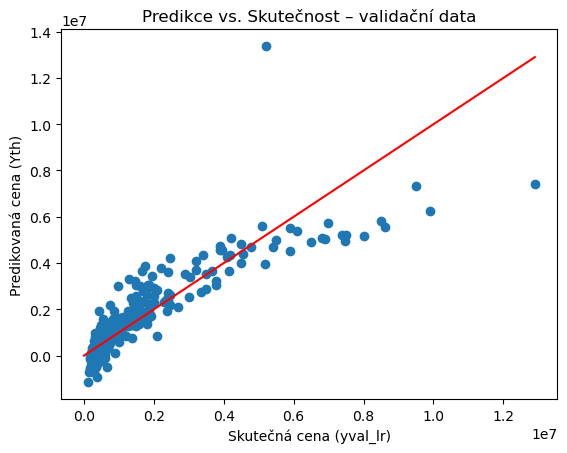

MSE (train): 	579127418339
MSE (valid): 	813936816957


In [31]:
opt_lr = train_lr(Xtrain_lr, ytrain_lr, Xval_lr, yval_lr)
print(f"Best scaler: {opt_lr['scaler']}")

sc_lr = opt_lr['scaler']
if sc_lr is not None:
    if sc_lr == 'standard':
        scaler = StandardScaler().fit(Xtrain_lr)
    else:
        scaler = MinMaxScaler().fit(Xtrain_lr)
    Xtrain_lr  = scaler.transform(Xtrain_lr)
    Xval_lr    = scaler.transform(Xval_lr)
    

reg = LinearRegression()
reg.fit(Xtrain_lr, ytrain_lr)

# Graph prediction to reality
Yth = reg.predict(Xval_lr)
plt.scatter(yval_lr, Yth)
maxprice = max(data['Price'])
plt.plot([0,maxprice], [0,maxprice], 'r')
plt.xlabel("Skutečná cena (yval_lr)")
plt.ylabel("Predikovaná cena (Yth)")
plt.title("Predikce vs. Skutečnost – validační data")
plt.show()

train_mse_lr = mean_squared_error(ytrain_lr, reg.predict(Xtrain_lr))
valid_mse_lr = mean_squared_error(yval_lr, reg.predict(Xval_lr))

print(f"MSE (train): \t{train_mse_lr:.0f}")
print(f"MSE (valid): \t{valid_mse_lr:.0f}")

Skutečně je vidět z grafu, že dražší auta podhodnocujeme a levnější nadhodnocujeme.

In [32]:
min_mse(model='linear', one_hot=True, scaler=sc_lr, params=None, new_mse=valid_mse_lr)

In [33]:
print_models()

model: knn	one-hot: False	scaler: standard,	params: ...	mse: 270804652612.149
model: tree	one-hot: True	scaler: None,		params: ...	mse: 372772024432.953
model: tree	one-hot: False	scaler: None,		params: ...	mse: 455778498491.238
model: knn	one-hot: True	scaler: standard,	params: ...	mse: 521523502356.930
model: linear	one-hot: True	scaler: standard,	params: ...	mse: 813936816957.013


Můžeme ještě zkusit zkoumat multikolinearitu v množině `Xtrain_lr`:

In [34]:
Xaug = np.matrix(np.concatenate([np.ones((Xtrain_lr.shape[0],1)),np.array(Xtrain_lr)], axis = 1))
print(f'Podmíněnost Xaug) (s one-hot-encodingem): {np.linalg.cond(Xaug.T)}')

Podmíněnost Xaug) (s one-hot-encodingem): 57.096821538350426


> The largest condition index is called the condition number. A condition number between 10 and 30 indicates the presence of multicollinearity and when a value is larger than 30, the multicollinearity is regarded as strong.

[Source](https://pmc.ncbi.nlm.nih.gov/articles/PMC6900425/#sec4)

Podle podmíněnosti můžeme očekávat silnou multikolinearitu, která může mít negativní dopad na kvalitu modelu.

#### Bez one-hot-encodingu.

In [35]:
Xtrain_lr, ytrain_lr = Xtrain.copy(), ytrain.copy()
Xval_lr, yval_lr     = Xval.copy(), yval.copy()

# One-hot-encoding
Xtrain_lr = drop_one_hot(Xtrain_lr)
Xval_lr   = drop_one_hot(Xval_lr)

# Impute NaNs
Xtrain_lr = impute_data(Xtrain_lr, Xtrain_lr)
Xval_lr   = impute_data(Xtrain_lr, Xval_lr)

Opět vybereme nejlepší scaler.

Best scaler: standard


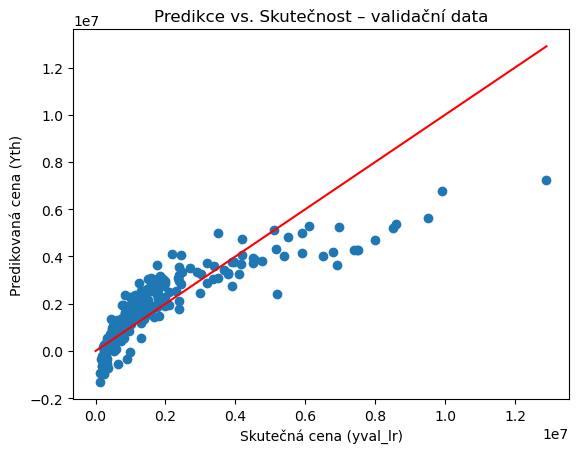

MSE (train): 	909114366148
MSE (valid): 	838081783979


In [36]:
opt_lr = train_lr(Xtrain_lr, ytrain_lr, Xval_lr, yval_lr)
print(f"Best scaler: {opt_lr['scaler']}")

sc_lr = opt_lr['scaler']
if sc_lr is not None:
    if sc_lr == 'standard':
        scaler = StandardScaler().fit(Xtrain_lr)
    else:
        scaler = MinMaxScaler().fit(Xtrain_lr)
    Xtrain_lr  = scaler.transform(Xtrain_lr)
    Xval_lr    = scaler.transform(Xval_lr)
    

reg = LinearRegression()
reg.fit(Xtrain_lr, ytrain_lr)

# Plot the prediction/reality graph
Yth = reg.predict(Xval_lr)
plt.scatter(yval_lr, Yth)
maxprice = max(data['Price'])
plt.plot([0,maxprice], [0,maxprice], 'r')
plt.xlabel("Skutečná cena (yval_lr)")
plt.ylabel("Predikovaná cena (Yth)")
plt.title("Predikce vs. Skutečnost – validační data")
plt.show()

train_mse_lr = mean_squared_error(ytrain_lr, reg.predict(Xtrain_lr))
valid_mse_lr = mean_squared_error(yval_lr, reg.predict(Xval_lr))

print(f"MSE (train): \t{train_mse_lr:.0f}")
print(f"MSE (valid): \t{valid_mse_lr:.0f}")

In [37]:
min_mse(model='linear', one_hot=False, scaler=sc_lr, params=None, new_mse=valid_mse_lr)

In [38]:
print_models()

model: knn	one-hot: False	scaler: standard,	params: ...	mse: 270804652612.149
model: tree	one-hot: True	scaler: None,		params: ...	mse: 372772024432.953
model: tree	one-hot: False	scaler: None,		params: ...	mse: 455778498491.238
model: knn	one-hot: True	scaler: standard,	params: ...	mse: 521523502356.930
model: linear	one-hot: True	scaler: standard,	params: ...	mse: 813936816957.013
model: linear	one-hot: False	scaler: standard,	params: ...	mse: 838081783978.994


Toto vede k ještě horšímu modelu.

In [39]:
Xaug = np.matrix(np.concatenate([np.ones((Xtrain_lr.shape[0],1)),np.array(Xtrain_lr)], axis = 1))
print(f'Podmíněnost Xaug) (bez one-hot-encodingem): {np.linalg.cond(Xaug)}')

Podmíněnost Xaug) (bez one-hot-encodingem): 8.651416278329402


I přes to, že se nám zlepšila podmíněnost.

### Hřebenová regrese:

Špatný výkon lineární regrese (nejspíše ale kvůli fundamentální nelinearitě predikce cen aut) naznačuje, že hřebenová regrese model výrazně nezlepší. Ale můžeme ji také zkusit, protože jsme zjistili náznaky multikolinearity.

#### One-Hot-Encoding:

In [40]:
from sklearn.linear_model import Ridge

In [41]:
Xtrain_rg, ytrain_rg = Xtrain.copy(), ytrain.copy()
Xval_rg, yval_rg     = Xval.copy(), yval.copy()

# One-hot-encoding
Xtrain_rg = data_one_hot(Xtrain_rg)
Xval_rg   = data_one_hot(Xval_rg)

# Impute NaNs
Xtrain_rg = impute_data(Xtrain_rg, Xtrain_rg)
Xval_rg   = impute_data(Xtrain_rg, Xval_rg)

In [42]:
from scipy import optimize

# Upravený kód ze cvičení
def get_opt_ridge_model(Xt, yt, Xv, yv, linrange):
    """
    Find optimal alpha for Ridge and picks the best for `standard` or `minmax` scaler or `None`.
    """
    scalers = [None, 'standard', 'minmax']
    
    best_overall = {
        'scaler': None,
        'alpha': 0,
        'valid_mse': np.inf
    }

    # Iterate through each scaler
    for sc in scalers:
        Xtrain_rg_s = Xt.copy()
        Xval_rg_s = Xv.copy()
        
        # Exclude bool from scaling
        cols = Xtrain_rg.select_dtypes(exclude = ["int8"]).columns.tolist()
        cols.append("Owner")
        
        if sc is not None:
            if sc == "standard":
                scaler = StandardScaler().fit(Xt[cols])
            else:
                scaler = MinMaxScaler().fit(Xt[cols])
            Xtrain_rg_s[cols] = scaler.transform(Xt[cols])
            Xval_rg_s[cols]   = scaler.transform(Xv[cols])
        
        def ridgemodel_eval(alpha):
            reg = Ridge(alpha=alpha)
            reg.fit(Xtrain_rg_s, yt)
            return mean_squared_error(yv, reg.predict(Xval_rg_s))

        # Find Ridge alpha automatically
        opt_alpha = optimize.minimize_scalar(
            ridgemodel_eval,
            options = {'maxiter': 30},
            method = 'bounded',
            bounds=(0.1, 400)
        )

        # Update best option
        if opt_alpha.fun < best_overall["valid_mse"]:
            best_overall["scaler"] = sc
            best_overall['alpha'] = opt_alpha.x
            best_overall["valid_mse"] = opt_alpha.fun
    
    return best_overall

In [43]:
lin_range = np.linspace(start=0, stop=5, num=100)
opt_rg = get_opt_ridge_model(Xtrain_rg, ytrain_rg, Xval_rg, yval_rg, lin_range)

sc_lr = opt_rg['scaler']
if sc_lr is not None:
    if sc_lr == 'standard':
        scaler = StandardScaler().fit(Xtrain_rg)
    else:
        scaler = MinMaxScaler().fit(Xtrain_rg)
    Xtrain_rg  = scaler.transform(Xtrain_rg)
    Xval_rg    = scaler.transform(Xval_rg)

reg = Ridge(alpha=opt_rg['alpha'])
reg.fit(Xtrain_rg, ytrain_rg);

Teď, když máme optimální alphu pro Ridge, porovnáme výsledky s lineární regresí.

Best scaler: None
Valid MSE: 633753353497.4142


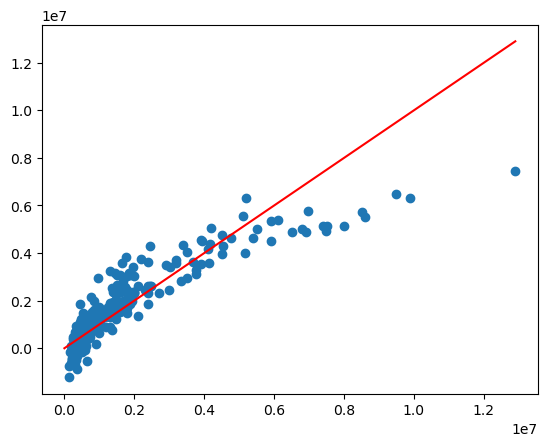

In [44]:
print(f"Best scaler: {opt_rg['scaler']}")
print(f"Valid MSE: {opt_rg['valid_mse']}")

plt.scatter(yval_rg, reg.predict(Xval_rg))
maxprice = max(data['Price'])
plt.plot([0,maxprice], [0,maxprice], 'r')
plt.show()

In [45]:
min_mse(model='ridge', one_hot=True, scaler=opt_rg['scaler'], params=None, new_mse=opt_rg['valid_mse'])

In [46]:
print_models()

model: knn	one-hot: False	scaler: standard,	params: ...	mse: 270804652612.149
model: tree	one-hot: True	scaler: None,		params: ...	mse: 372772024432.953
model: tree	one-hot: False	scaler: None,		params: ...	mse: 455778498491.238
model: knn	one-hot: True	scaler: standard,	params: ...	mse: 521523502356.930
model: ridge	one-hot: True	scaler: None,		params: ...	mse: 633753353497.414
model: linear	one-hot: True	scaler: standard,	params: ...	mse: 813936816957.013
model: linear	one-hot: False	scaler: standard,	params: ...	mse: 838081783978.994


A skutečně `Ridge regrese` nám výšla výrazně lépe než `Linear`, ale stále to nestačí na ostatní modely.

Můžeme ještě zkusit dropnout příznaky, ale zde bych čekal zhoršení a podobný výsledek jako u `Linear` bez one-hot-encodingu.

#### Bez one-hot-encodingu:

In [47]:
Xtrain_rg, ytrain_rg = Xtrain.copy(), ytrain.copy()
Xval_rg, yval_rg     = Xval.copy(), yval.copy()

# One-hot-encoding
Xtrain_rg = drop_one_hot(Xtrain_rg)
Xval_rg   = drop_one_hot(Xval_rg)

# Impute NaNs
Xtrain_rg = impute_data(Xtrain_rg, Xtrain_rg)
Xval_rg   = impute_data(Xtrain_rg, Xval_rg)

In [48]:
lin_range = np.linspace(start=0, stop=5, num=100)
opt_rg = get_opt_ridge_model(Xtrain_rg, ytrain_rg, Xval_rg, yval_rg, lin_range)

sc_lr = opt_rg['scaler']
if sc_lr is not None:
    if sc_lr == 'standard':
        scaler = StandardScaler().fit(Xtrain_rg)
    else:
        scaler = MinMaxScaler().fit(Xtrain_rg)
    Xtrain_rg  = scaler.transform(Xtrain_rg)
    Xval_rg    = scaler.transform(Xval_rg)

reg = Ridge(alpha=opt_rg['alpha'])
reg.fit(Xtrain_rg, ytrain_rg);

Best scaler: None
Valid MSE: 824641075016.3301


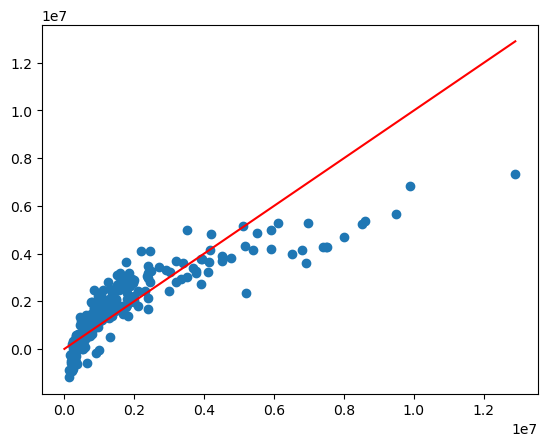

In [49]:
print(f"Best scaler: {opt_rg['scaler']}")
print(f"Valid MSE: {opt_rg['valid_mse']}")

plt.scatter(yval_rg, reg.predict(Xval_rg))
maxprice = max(data['Price'])
plt.plot([0,maxprice], [0,maxprice], 'r')
plt.show()

In [50]:
min_mse(model='ridge', one_hot=False, scaler=opt_rg['scaler'], params=None, new_mse=opt_rg['valid_mse'])

In [51]:
print_models()

model: knn	one-hot: False	scaler: standard,	params: ...	mse: 270804652612.149
model: tree	one-hot: True	scaler: None,		params: ...	mse: 372772024432.953
model: tree	one-hot: False	scaler: None,		params: ...	mse: 455778498491.238
model: knn	one-hot: True	scaler: standard,	params: ...	mse: 521523502356.930
model: ridge	one-hot: True	scaler: None,		params: ...	mse: 633753353497.414
model: linear	one-hot: True	scaler: standard,	params: ...	mse: 813936816957.013
model: ridge	one-hot: False	scaler: None,		params: ...	mse: 824641075016.330
model: linear	one-hot: False	scaler: standard,	params: ...	mse: 838081783978.994


Takže vidíme, že `Ridge` s one-hot-encodingem docela pomohl, ale stále predikovat hodnoty lineárně vychází nejhůře.

## Porovnání všech modelů a výběr nejlepšího:

In [52]:
print_models(rmse=True)

model: knn	one-hot: False	scaler: standard,	params: ...	rmse: 520388.944
model: tree	one-hot: True	scaler: None,		params: ...	rmse: 610550.591
model: tree	one-hot: False	scaler: None,		params: ...	rmse: 675113.693
model: knn	one-hot: True	scaler: standard,	params: ...	rmse: 722165.841
model: ridge	one-hot: True	scaler: None,		params: ...	rmse: 796086.273
model: linear	one-hot: True	scaler: standard,	params: ...	rmse: 902184.469
model: ridge	one-hot: False	scaler: None,		params: ...	rmse: 908097.503
model: linear	one-hot: False	scaler: standard,	params: ...	rmse: 915468.068


Vidíme, že **kNN** *bez one-hot-encodingu* a se *standardizací* vychází nejlépe podle (R)MSE na validační množině a tento model využijeme pro **finální predikci**.

## Realizace nejlepšího modelu:

In [53]:
# Data preprocessing
Xtrain_final = Xtrain.copy()
Xval_final   = Xval.copy()
Xtest_final  = Xtest.copy()

Xtrain_final = data_processing(Xtrain_final)
Xtrain_final = drop_one_hot(Xtrain_final)
Xtrain_final = impute_data(Xtrain_final, Xtrain_final)

Xval_final   = data_processing(Xval_final)
Xval_final   = drop_one_hot(Xval_final)
Xval_final   = impute_data(Xtrain_final, Xval_final)

Xtest_final  = data_processing(Xtest_final)
Xtest_final  = drop_one_hot(Xtest_final)
Xtest_final  = impute_data(Xtrain_final, Xtest_final)

final_scaler = StandardScaler().fit(Xtrain_final)
Xtrain_final = final_scaler.transform(Xtrain_final)
Xval_final   = final_scaler.transform(Xval_final)
Xtest_final  = final_scaler.transform(Xtest_final)

In [54]:
ideal_model = MINIMAL_MSE_MODEL

final = KNeighborsRegressor(**ideal_model['params'])
final.fit(Xtrain_final, ytrain)

KNeighborsRegressor(metric='manhattan', n_neighbors=4, weights='distance')

## Odhat přesnosti na trénovací množině:

In [55]:
print(f"Predicted RMSE for best model (val):  {root_mean_squared_error(yval, final.predict(Xval_final)):.0f}")
print(f"Predicted RMSE for best model (test): {root_mean_squared_error(ytest, final.predict(Xtest_final)):.0f}")

Predicted RMSE for best model (val):  520389
Predicted RMSE for best model (test): 711597


Můžeme očekávat RMSE u finálního modelu kolem **711 tisíc**, takže bychom se mohli vejít do požadováného limitu **765 000**.

## Skutečná predikce:

In [56]:
# Read the data
evaluate = pd.read_csv('evaluation.csv')
evaluate_ids = evaluate["ID"].copy() # Store id's

# Prepate Xtrain for imputer
Xtrain_eval = Xtrain.copy()
Xtrain_eval = data_processing(Xtrain_eval)
Xtrain_eval = drop_one_hot(Xtrain_eval)

# Prepare the data
evaluate = data_processing(evaluate)
evaluate = drop_one_hot(evaluate)
evaluate = impute_data(Xtrain_eval, evaluate) # Xtrain

eval_scaler = StandardScaler().fit(Xtrain_eval)
evaluate_scaled = eval_scaler.transform(evaluate)

# Predict
predict = final.predict(evaluate_scaled)

# Store into DataFrame
results = pd.DataFrame({
    "ID": evaluate_ids,
    "Price": predict
})

# Save to CSV
results.to_csv("results.csv", index=False)

## Zdroje:

* [scikit-learn dokumentace](https://scikit-learn.org/stable/)
* [pandas dokumentace](https://pandas.pydata.org/docs/)
* [Multikolinearita](https://en.wikipedia.org/wiki/Multicollinearity)
* [Podmíněnost matice](https://en.wikipedia.org/wiki/Condition_number)
* Některé části kódu byly převzány a řádně upraveny ze cvičení.
* Některé komentáře a markdown texty byly upraveny jazykovými modely, aby zněly lépe a byly bez gramatických chyb.